# Evaluación Formativa 1 — Código del informe
## Dataset: *E-Commerce Shipping Data* (entregas atrasadas)

**MCDI501 - Estadística Computacional para la Toma de Decisiones**
Magíster en Ciencia de Datos e Inteligencia Artificial, Universidad Andrés Bello
Equipo: José Ignacio Rodríguez, Yerko Gallardo y Sebastián Rojas

Este cuaderno reproduce los resultados del informe y sigue su mismo orden:

0. Configuración y carga de datos
1. Estadística descriptiva (ID1.2): tipos de variables, medidas resumen, frecuencias, calidad de datos y análisis exploratorio (EDA)
2. Estimación puntual e intervalos de confianza (ID1.3)
3. Pruebas de hipótesis (ID1.4)
4. Síntesis

## 0. Configuración y carga de datos

El archivo original `data/raw/ecommerce_shipping.csv` no se modifica. La base de trabajo `df` solo cambia
los nombres de las columnas y agrega `entrega_atrasada` (1 = atrasada, 0 = a tiempo). No se eliminan filas.

In [1]:
from pathlib import Path
import pandas as pd

# Raíz del proyecto: funciona al ejecutar desde la raíz o desde notebooks/
RAIZ = Path.cwd().resolve()
while not (RAIZ / 'pyproject.toml').exists():
    RAIZ = RAIZ.parent

raw = pd.read_csv(RAIZ / 'data/raw/ecommerce_shipping.csv', encoding='utf-8-sig')

NOMBRES = {
    'ID': 'id_envio', 'Warehouse_block': 'bloque_bodega', 'Mode_of_Shipment': 'modalidad_envio',
    'Customer_care_calls': 'llamadas_atencion', 'Customer_rating': 'calificacion_cliente',
    'Cost_of_the_Product': 'costo_producto', 'Prior_purchases': 'compras_previas',
    'Product_importance': 'importancia_producto', 'Gender': 'genero',
    'Discount_offered': 'descuento_ofrecido', 'Weight_in_gms': 'peso_gramos',
}
TARGET = 'entrega_atrasada'

df = raw.rename(columns=NOMBRES)
df[TARGET] = raw['Reached.on.Time_Y.N']
df['importancia_producto'] = pd.Categorical(df['importancia_producto'],
                                            categories=['low', 'medium', 'high'], ordered=True)

n = len(df)
print('Dimensiones:', df.shape)
df.head()

Dimensiones: (10999, 13)


,id_envio,bloque_bodega,modalidad_envio,llamadas_atencion,calificacion_cliente,costo_producto,compras_previas,importancia_producto,genero,descuento_ofrecido,peso_gramos,Reached.on.Time_Y.N,entrega_atrasada
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1,1


## 1. Estadística descriptiva (ID1.2)

### 1.1 Tipos de variables y medidas resumen
Doce variables: un identificador, el resultado binario (`entrega_atrasada`), cinco cuantitativas (llamadas,
costo, compras previas, descuento y peso), tres nominales (bodega, modalidad y género) y dos ordinales
(calificación e importancia). La columna original del resultado (`Reached.on.Time_Y.N`) se conserva en `df`.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id_envio              10999 non-null  int64   
 1   bloque_bodega         10999 non-null  str     
 2   modalidad_envio       10999 non-null  str     
 3   llamadas_atencion     10999 non-null  int64   
 4   calificacion_cliente  10999 non-null  int64   
 5   costo_producto        10999 non-null  int64   
 6   compras_previas       10999 non-null  int64   
 7   importancia_producto  10999 non-null  category
 8   genero                10999 non-null  str     
 9   descuento_ofrecido    10999 non-null  int64   
 10  peso_gramos           10999 non-null  int64   
 11  Reached.on.Time_Y.N   10999 non-null  int64   
 12  entrega_atrasada      10999 non-null  int64   
dtypes: category(1), int64(9), str(3)
memory usage: 1.0 MB


In [3]:
tipos = pd.Series({
    'id_envio': 'Identificador (nominal)',
    'bloque_bodega': 'Cualitativa nominal',
    'modalidad_envio': 'Cualitativa nominal',
    'llamadas_atencion': 'Cuantitativa discreta (conteo)',
    'calificacion_cliente': 'Cualitativa ordinal (1 a 5)',
    'costo_producto': 'Cuantitativa de razón (USD)',
    'compras_previas': 'Cuantitativa discreta (conteo)',
    'importancia_producto': 'Cualitativa ordinal (low < medium < high)',
    'genero': 'Cualitativa nominal',
    'descuento_ofrecido': 'Cuantitativa (unidad no especificada)',
    'peso_gramos': 'Cuantitativa de razón (gramos)',
    'entrega_atrasada': 'Nominal binaria (resultado; 1 = atrasada)',
}, name='Tipo')
tipos.to_frame()

,Tipo
id_envio,Identificador (nominal)
bloque_bodega,Cualitativa nominal
modalidad_envio,Cualitativa nominal
llamadas_atencion,Cuantitativa discreta (conteo)
calificacion_cliente,Cualitativa ordinal (1 a 5)
costo_producto,Cuantitativa de razón (USD)
compras_previas,Cuantitativa discreta (conteo)
importancia_producto,Cualitativa ordinal (low < medium < high)
genero,Cualitativa nominal
descuento_ofrecido,Cuantitativa (unidad no especificada)


#### Clasificación programática de las variables
Las listas de variables se derivan de los datos (no se escriben a mano):

- **Identificadores**: columnas con un valor distinto por fila; se excluyen del análisis.
- **Variable dependiente**: `entrega_atrasada` (se excluye también su columna original `Reached.on.Time_Y.N`).
- **Cuantitativas**: numéricas con más de `MAX_NIVELES` valores distintos.
- **Cualitativas**: texto/categóricas y numéricas con pocos niveles (p. ej. la calificación 1 a 5, que es ordinal).

Se verifica que el resultado coincida con la tabla de tipos anterior.

In [4]:
MAX_NIVELES = 5   # una numérica con 5 niveles o menos se trata como código cualitativo

ids = [c for c in df.columns if df[c].nunique() == n]
excluir = set(ids) | {TARGET, 'Reached.on.Time_Y.N'}
predictoras = [c for c in df.columns if c not in excluir]

cuantitativas = [c for c in predictoras
                 if pd.api.types.is_numeric_dtype(df[c]) and df[c].nunique() > MAX_NIVELES]
cualitativas = [c for c in predictoras if c not in cuantitativas]

# Coherencia con la tabla de tipos
assert set(cuantitativas) == set(tipos[tipos.str.startswith('Cuantitativa')].index)
assert set(cualitativas) == set(tipos[tipos.str.startswith('Cualitativa')].index)

print('Identificadores      :', ids)
print('Variable dependiente :', TARGET)
print('Cuantitativas        :', cuantitativas)
print('Cualitativas         :', cualitativas)

Identificadores      : ['id_envio']
Variable dependiente : entrega_atrasada
Cuantitativas        : ['llamadas_atencion', 'costo_producto', 'compras_previas', 'descuento_ofrecido', 'peso_gramos']
Cualitativas         : ['bloque_bodega', 'modalidad_envio', 'calificacion_cliente', 'importancia_producto', 'genero']


Medidas resumen de las variables cuantitativas (se excluyen el identificador, los códigos nominales y las
ordinales). Se agrega el rango intercuartílico (IQR) y la asimetría. Resultado exportado a
`outputs/tablas/descriptiva_cuantitativas.csv`.

In [5]:
desc = df[cuantitativas].describe().T
desc['IQR'] = desc['75%'] - desc['25%']
desc['asimetria'] = df[cuantitativas].skew()

(RAIZ / 'outputs/tablas').mkdir(parents=True, exist_ok=True)
desc.to_csv(RAIZ / 'outputs/tablas/descriptiva_cuantitativas.csv', encoding='utf-8')
desc.round(2)

,count,mean,std,min,25%,50%,75%,max,IQR,asimetria
llamadas_atencion,10999.0,4.05,1.14,2.0,3.0,4.0,5.0,7.0,2.0,0.39
costo_producto,10999.0,210.20,48.06,96.0,169.0,214.0,251.0,310.0,82.0,-0.16
compras_previas,10999.0,3.57,1.52,2.0,3.0,3.0,4.0,10.0,1.0,1.68
descuento_ofrecido,10999.0,13.37,16.21,1.0,4.0,7.0,10.0,65.0,6.0,1.80
peso_gramos,10999.0,3634.02,1635.38,1001.0,1839.5,4149.0,5050.0,7846.0,3210.5,-0.25


### 1.2 Frecuencias de las variables cualitativas
Frecuencias absolutas y porcentajes, con las ordinales en su orden natural. Resultado exportado a
`outputs/tablas/frecuencias.csv`.

In [6]:
partes = []
for v in [TARGET] + cualitativas:
    t = df[v].value_counts().sort_index().rename('n').to_frame()   # respeta el orden de las ordinales
    t['porcentaje'] = t['n'] / n * 100
    t.insert(0, 'categoria', t.index.astype(str))
    t.insert(0, 'variable', v)
    assert t['n'].sum() == n          # las frecuencias suman el total
    partes.append(t)

frecuencias = pd.concat(partes, ignore_index=True)
frecuencias.to_csv(RAIZ / 'outputs/tablas/frecuencias.csv', index=False, encoding='utf-8')

r = df['calificacion_cliente']
print(f"Calificación: mediana = {r.median():g}, Q1 = {r.quantile(0.25):g}, Q3 = {r.quantile(0.75):g}")
cod = int(df['importancia_producto'].cat.codes.median())
print(f"Importancia : mediana = {df['importancia_producto'].cat.categories[cod]}")
frecuencias.round(2)

Calificación: mediana = 3, Q1 = 2, Q3 = 4
Importancia : mediana = medium


,variable,categoria,n,porcentaje
0,entrega_atrasada,0,4436,40.33
1,entrega_atrasada,1,6563,59.67
2,bloque_bodega,A,1833,16.67
3,bloque_bodega,B,1833,16.67
4,bloque_bodega,C,1833,16.67
5,bloque_bodega,D,1834,16.67
6,bloque_bodega,F,3666,33.33
7,modalidad_envio,Flight,1777,16.16
8,modalidad_envio,Road,1760,16.00
9,modalidad_envio,Ship,7462,67.84


### 1.3 Calidad de datos
Nulos, duplicados, unicidad del identificador y tasa de atraso.

In [7]:
sin_id = [c for c in raw.columns if c != 'ID']

print(f"Registros                  : {n:,}")
print(f"Celdas vacías              : {raw.isna().sum().sum()}")
print(f"ID únicos                  : {df['id_envio'].nunique():,}")
print(f"Duplicados con ID          : {raw.duplicated().sum()}")
print(f"Duplicados sin ID          : {raw.duplicated(subset=sin_id).sum()}")
print(f"Entregas atrasadas         : {df[TARGET].sum():,} ({df[TARGET].mean()*100:.1f}%)")
print(f"Entregas a tiempo          : {(df[TARGET] == 0).sum():,} ({(1 - df[TARGET].mean())*100:.1f}%)")
print('Bodegas:', df['bloque_bodega'].value_counts().sort_index().to_dict())

Registros                  : 10,999
Celdas vacías              : 0
ID únicos                  : 10,999
Duplicados con ID          : 0
Duplicados sin ID          : 0
Entregas atrasadas         : 6,563 (59.7%)
Entregas a tiempo          : 4,436 (40.3%)
Bodegas: {'A': 1833, 'B': 1833, 'C': 1833, 'D': 1834, 'F': 3666}


### 1.4 Tabla de controles
Resumen de los controles, exportado a `outputs/tablas/calidad_datos.csv`. Estados: OK, ALERTA (revisar) e
INFO (extremos válidos, no es un error).

In [8]:
filas = []
def control(nombre, variable, esperado, observado, ok, detalle=''):
    filas.append((nombre, variable, esperado, observado, 'OK' if ok else 'ALERTA', detalle))

control('filas', 'todas', n, len(df), len(df) == n, 'Sin exclusiones de filas')
control('nulos_totales', 'todas', 0, int(raw.isna().sum().sum()), raw.isna().sum().sum() == 0, 'Sin imputación ni faltantes artificiales')
control('id_unico', 'id_envio', n, int(df['id_envio'].nunique()), df['id_envio'].is_unique, 'No prueba independencia ni un registro por cliente')

dominios = {'bloque_bodega': ['A', 'B', 'C', 'D', 'F'], 'modalidad_envio': ['Flight', 'Road', 'Ship'], 'genero': ['F', 'M']}
for v, esperado in dominios.items():
    obs = sorted(df[v].unique())
    control('dominio_categorico', v, esperado, obs, obs == esperado, 'F no se recodifica a E' if v == 'bloque_bodega' else '')
    control('suma_frecuencias', v, n, int(df[v].value_counts().sum()), df[v].value_counts().sum() == n)

obs = sorted(df['importancia_producto'].dropna().astype(str).unique())
control('dominio_ordinal', 'importancia_producto', 'low<medium<high', obs, obs == ['high', 'low', 'medium'])
control('dominio_ordinal', 'calificacion_cliente', '1..5', f"{df['calificacion_cliente'].min()}..{df['calificacion_cliente'].max()}", df['calificacion_cliente'].between(1, 5).all())
control('resultado_binario', TARGET, '{0,1}', sorted(df[TARGET].unique().tolist()), set(df[TARGET]) <= {0, 1},
        f"1 (atrasada)={df[TARGET].sum()}; 0 (a tiempo)={(df[TARGET] == 0).sum()}")
control('alias_igual_original', TARGET, 0, int((df[TARGET] != raw['Reached.on.Time_Y.N']).sum()), (df[TARGET] == raw['Reached.on.Time_Y.N']).all())

numericas = ['llamadas_atencion', 'costo_producto', 'compras_previas', 'descuento_ofrecido', 'peso_gramos']
for v in numericas:
    s = df[v]
    q1, q3 = s.quantile([0.25, 0.75])
    bajo, alto = int((s < q1 - 1.5 * (q3 - q1)).sum()), int((s > q3 + 1.5 * (q3 - q1)).sum())
    control('rango_valido', v, '>0', f'{s.min()}..{s.max()}', (s > 0).all())
    filas.append(('extremos_regla_IQR', v, 'conservar', f'bajo={bajo}; alto={alto}', 'INFO' if bajo + alto else 'OK',
                  'Valores válidos; no se eliminan' if bajo + alto else ''))

control('duplicados_con_ID', 'todas', 0, int(raw.duplicated().sum()), not raw.duplicated().any())
control('duplicados_sin_ID', 'todas menos ID', 0, int(raw.duplicated(subset=sin_id).sum()), not raw.duplicated(subset=sin_id).any(),
        'Perfiles idénticos no se eliminan automáticamente')

calidad = pd.DataFrame(filas, columns=['control', 'variable', 'esperado', 'observado', 'estado', 'detalle'])
(RAIZ / 'outputs/tablas').mkdir(parents=True, exist_ok=True)
calidad.to_csv(RAIZ / 'outputs/tablas/calidad_datos.csv', index=False, encoding='utf-8')

print(calidad['estado'].value_counts().to_dict())
calidad[['control', 'variable', 'observado', 'estado']]

{'OK': 23, 'INFO': 2}


,control,variable,observado,estado
0,filas,todas,10999,OK
1,nulos_totales,todas,0,OK
2,id_unico,id_envio,10999,OK
3,dominio_categorico,bloque_bodega,"[A, B, C, D, F]",OK
4,suma_frecuencias,bloque_bodega,10999,OK
5,dominio_categorico,modalidad_envio,"[Flight, Road, Ship]",OK
6,suma_frecuencias,modalidad_envio,10999,OK
7,dominio_categorico,genero,"[F, M]",OK
8,suma_frecuencias,genero,10999,OK
9,dominio_ordinal,importancia_producto,"[high, low, medium]",OK


### 1.5 Análisis exploratorio (EDA)
Orden: (a) variable dependiente, (b) cuantitativas independientes, (c) cualitativas independientes,
(d) relaciones entre cuantitativas, (e) relación de la variable dependiente con cada predictora,
(f) interacción descuento × peso, (g) asociación entre cualitativas y (h) síntesis.
Los identificadores se excluyen. Las figuras se exportan a `outputs/figuras/fig_eda_*.png`.

#### Estilo de las figuras
Paleta común: fondo crema, verde azulado para la serie principal y terracota para las entregas atrasadas.

In [9]:
import matplotlib.pyplot as plt

TEAL  = '#1f5f8b'   # serie principal
TERRA = '#d1603d'   # entregas atrasadas
BG    = '#ffffff'   # fondo de los ejes
GRID  = '#e1e4e8'   # líneas de grilla

plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 200,
    'font.family': 'serif', 'font.size': 10,
    'axes.facecolor': BG, 'axes.edgecolor': '#8c8578',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.titleweight': 'normal', 'axes.titlelocation': 'left',
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
})
(RAIZ / 'outputs/figuras').mkdir(parents=True, exist_ok=True)

In [10]:
import numpy as np
import seaborn as sns
from scipy.stats.contingency import association

ETIQ_TARGET = {0: 'A tiempo (0)', 1: 'Atrasada (1)'}
PAL_TARGET = {ETIQ_TARGET[0]: TEAL, ETIQ_TARGET[1]: TERRA}
tasa_global = df[TARGET].mean()


def rejilla(k, ncols=3, alto=3.2, ancho=4.6):
    """Figura con k paneles en ncols columnas; oculta los ejes sobrantes."""
    nfilas = int(np.ceil(k / ncols))
    fig, ax = plt.subplots(nfilas, ncols, figsize=(ancho * ncols, alto * nfilas), squeeze=False)
    for a in ax.flat[k:]:
        a.set_visible(False)
    return fig, ax.flat[:k]


def guardar(nombre):
    plt.tight_layout()
    plt.savefig(RAIZ / f'outputs/figuras/{nombre}.png', bbox_inches='tight')
    plt.show()

#### (a) Variable dependiente: `entrega_atrasada`
Frecuencia absoluta y relativa de cada resultado. El desbalance (≈60/40) es moderado: no impide comparar
grupos, pero las tasas por categoría deben leerse contra la tasa global.

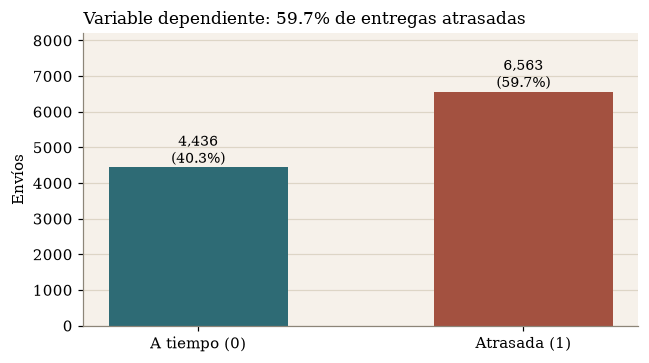

In [11]:
conteo = df[TARGET].map(ETIQ_TARGET).value_counts().reindex(ETIQ_TARGET.values())

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.bar(conteo.index, conteo.values, color=[TEAL, TERRA], width=0.55)
for i, v in enumerate(conteo.values):
    ax.text(i, v + conteo.max() * 0.02, f'{v:,}\n({v/n*100:.1f}%)', ha='center', fontsize=9)
ax.set_ylim(0, conteo.max() * 1.25)
ax.set_ylabel('Envíos')
ax.set_title(f'Variable dependiente: {tasa_global*100:.1f}% de entregas atrasadas')
ax.grid(axis='x', visible=False)
guardar('fig_eda_1_dependiente')

#### (b) Variables independientes cuantitativas
Histograma (con densidad) y diagrama de caja por variable. Las de conteo (pocos valores distintos) se
grafican con barras discretas.

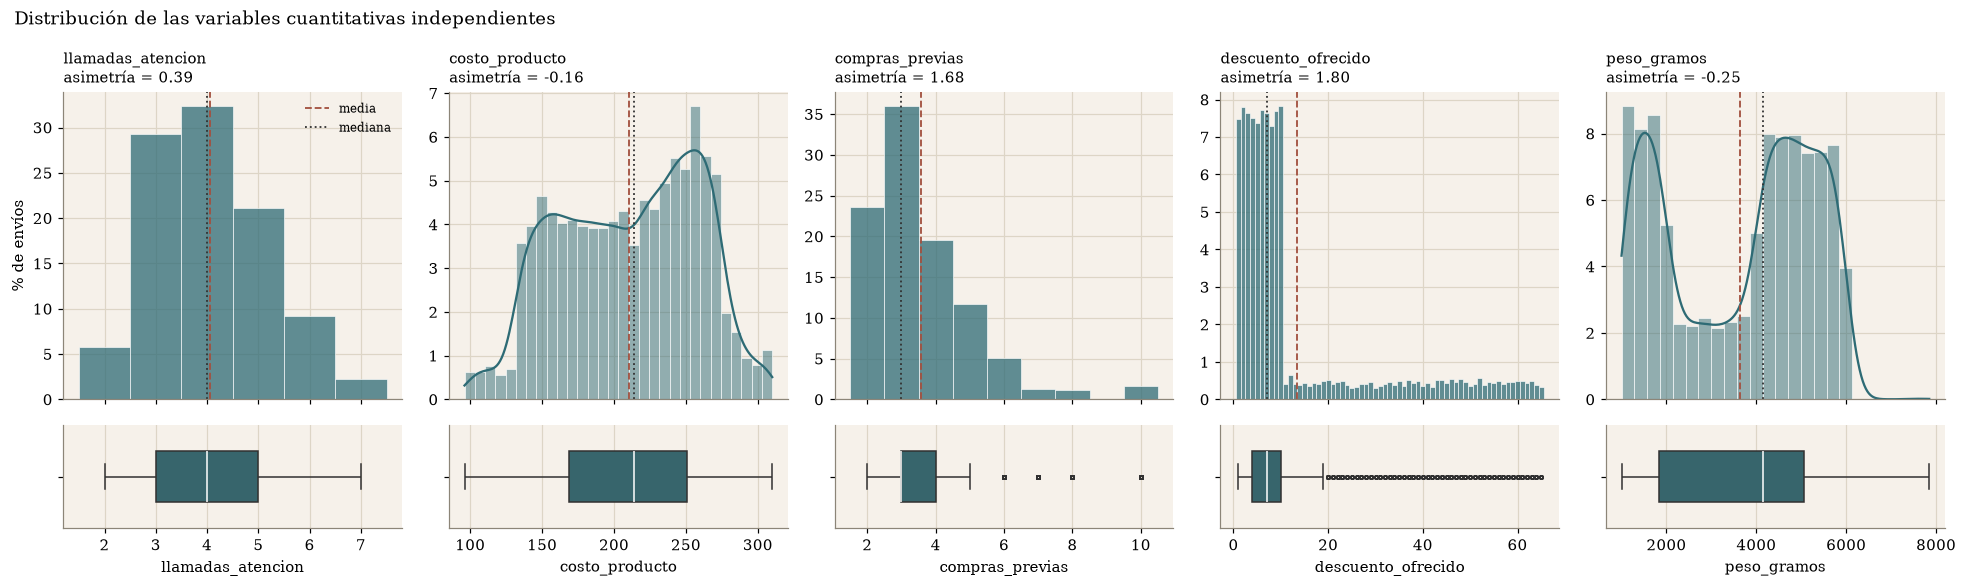

In [12]:
k = len(cuantitativas)
fig, ax = plt.subplots(2, k, figsize=(3.6 * k, 5.4), gridspec_kw={'height_ratios': [3, 1]}, sharex='col')
for j, v in enumerate(cuantitativas):
    s = df[v]
    discreta = pd.api.types.is_integer_dtype(s) and s.nunique() <= 70   # un bin por valor entero
    sns.histplot(s, ax=ax[0, j], color=TEAL, discrete=discreta, kde=not discreta,
                 stat='percent', edgecolor='white', linewidth=0.4)
    ax[0, j].axvline(s.mean(), color=TERRA, lw=1.2, ls='--', label='media')
    ax[0, j].axvline(s.median(), color='#333333', lw=1.2, ls=':', label='mediana')
    ax[0, j].set_title(f'{v}\nasimetría = {s.skew():.2f}', fontsize=10)
    ax[0, j].set_xlabel('')
    ax[0, j].set_ylabel('% de envíos' if j == 0 else '')
    sns.boxplot(x=s, ax=ax[1, j], color=TEAL, width=0.5, fliersize=2,
                flierprops={'alpha': 0.4}, medianprops={'color': 'white'})
    ax[1, j].set_xlabel(v)
ax[0, 0].legend(fontsize=8, frameon=False)
fig.suptitle('Distribución de las variables cuantitativas independientes', x=0.01, ha='left', fontsize=12)
guardar('fig_eda_2_cuantitativas')

#### (c) Variables independientes cualitativas
Frecuencia relativa de cada categoría. Las ordinales (`calificacion_cliente`, `importancia_producto`)
conservan su orden natural; las nominales se ordenan de mayor a menor frecuencia.

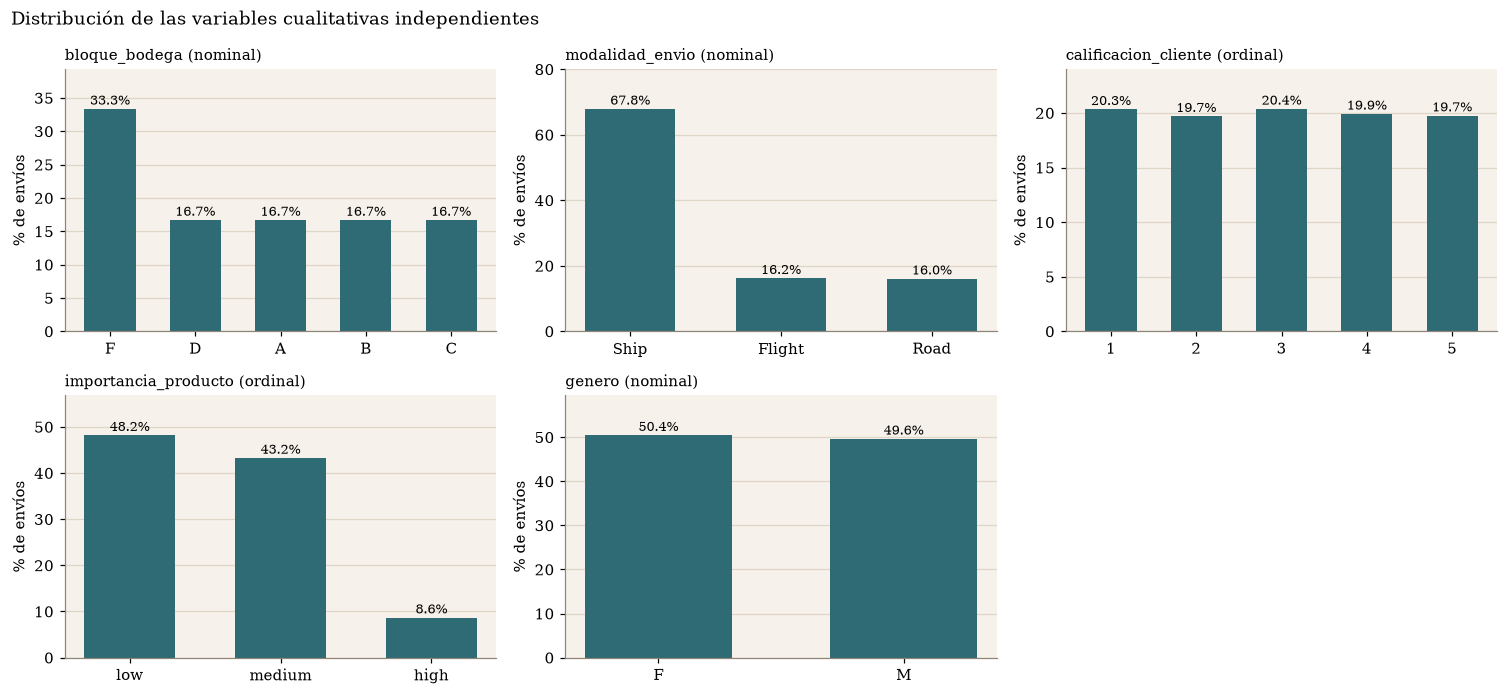

In [13]:
def es_ordinal(v):
    return isinstance(df[v].dtype, pd.CategoricalDtype) and df[v].cat.ordered or pd.api.types.is_numeric_dtype(df[v])

fig, ax = rejilla(len(cualitativas))
for a, v in zip(ax, cualitativas):
    frec = df[v].value_counts(normalize=True) * 100
    frec = frec.sort_index() if es_ordinal(v) else frec.sort_values(ascending=False)
    a.bar(frec.index.astype(str), frec.values, color=TEAL, width=0.6)
    for i, p in enumerate(frec.values):
        a.text(i, p + frec.max() * 0.02, f'{p:.1f}%', ha='center', fontsize=8.5)
    a.set_ylim(0, frec.max() * 1.18)
    a.set_title(f"{v} ({'ordinal' if es_ordinal(v) else 'nominal'})", fontsize=10)
    a.set_ylabel('% de envíos')
    a.grid(axis='x', visible=False)
fig.suptitle('Distribución de las variables cualitativas independientes', x=0.01, ha='left', fontsize=12)
guardar('fig_eda_3_cualitativas')

#### (d) Relaciones entre las variables cuantitativas
*Pairplot* de las cuantitativas coloreado por la variable dependiente (diagonal: densidades por grupo), y
matriz de correlación de Spearman (robusta a asimetría y a relaciones monótonas no lineales).

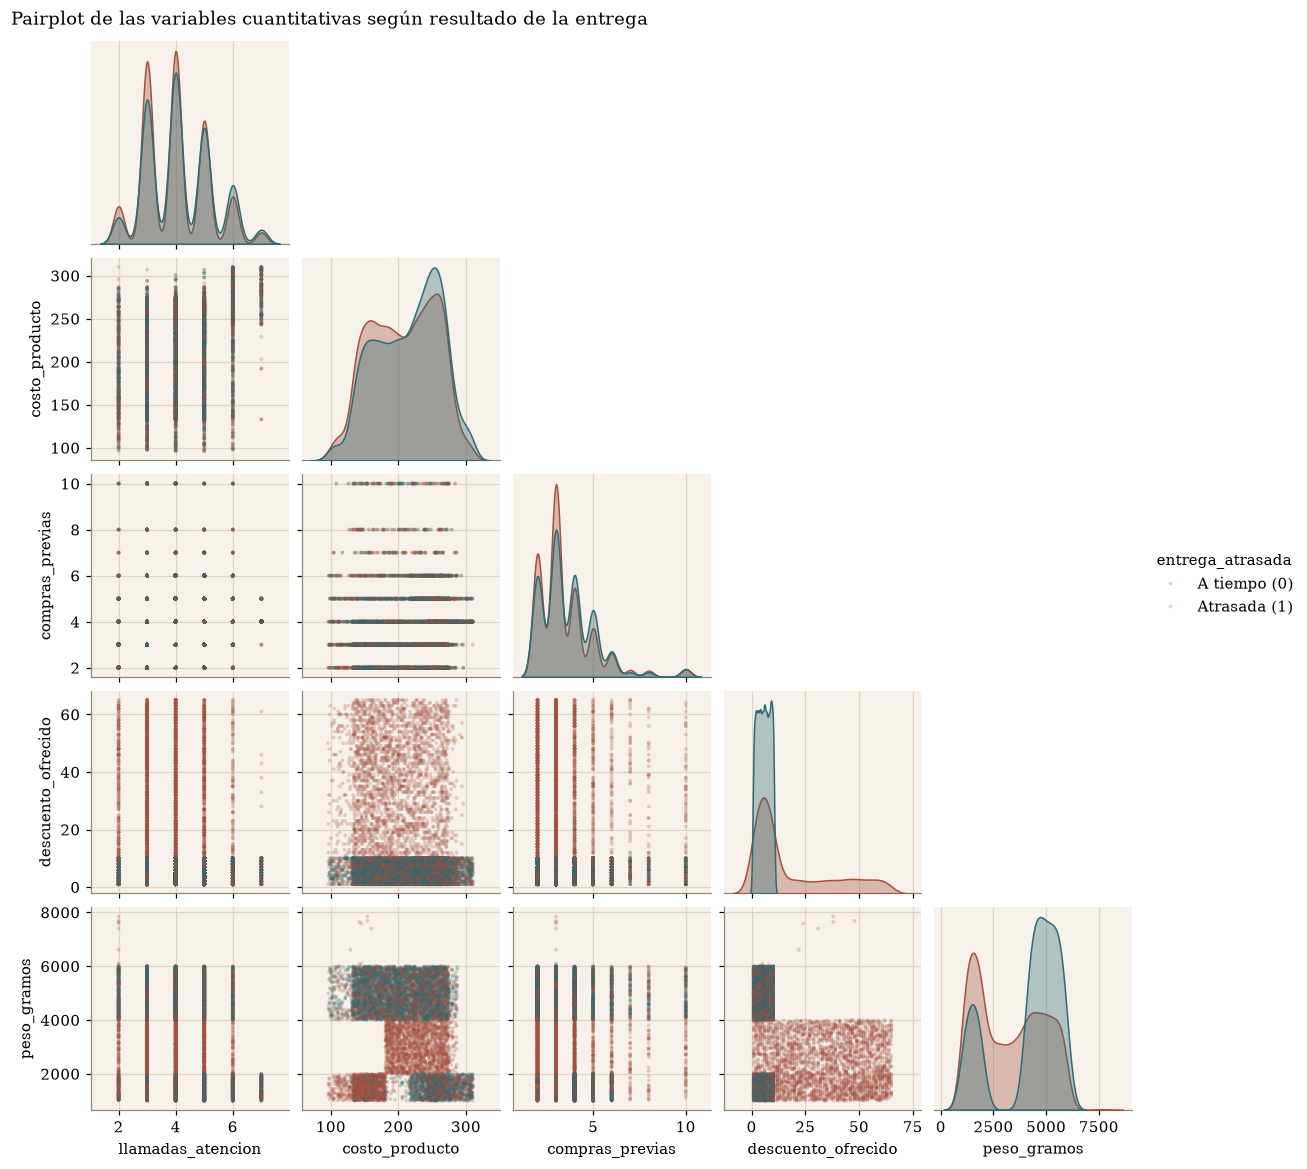

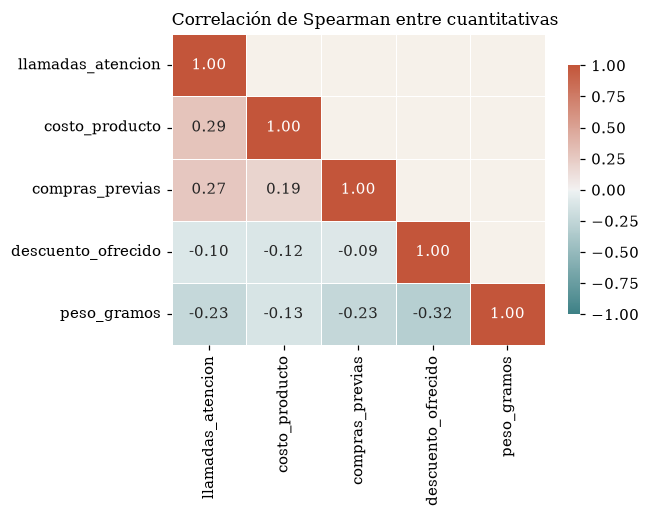

In [14]:
datos_pair = df[cuantitativas].assign(**{TARGET: df[TARGET].map(ETIQ_TARGET)})
g = sns.pairplot(datos_pair, hue=TARGET, palette=PAL_TARGET, hue_order=list(ETIQ_TARGET.values()),
                 corner=True, height=2.1,
                 plot_kws={'s': 6, 'alpha': 0.25, 'linewidth': 0},
                 diag_kws={'common_norm': False, 'fill': True, 'alpha': 0.35})
g.figure.suptitle('Pairplot de las variables cuantitativas según resultado de la entrega', x=0.01, ha='left', y=1.01)
g.savefig(RAIZ / 'outputs/figuras/fig_eda_4_pairplot.png', bbox_inches='tight')
plt.show()

corr = df[cuantitativas].corr(method='spearman')
fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt='.2f',
            cmap=sns.diverging_palette(200, 20, as_cmap=True), vmin=-1, vmax=1, center=0,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.grid(False)
ax.set_title('Correlación de Spearman entre cuantitativas')
guardar('fig_eda_5_correlacion')

#### (e) Relación de la variable dependiente con las predictoras
**Cuantitativas.** Arriba: distribución de cada variable según el resultado. Abajo: tasa de atraso por
valor (variables de conteo) o por quintil (continuas), con la tasa global como referencia. La tabla
resume medias y medianas por grupo y la *d* de Cohen.

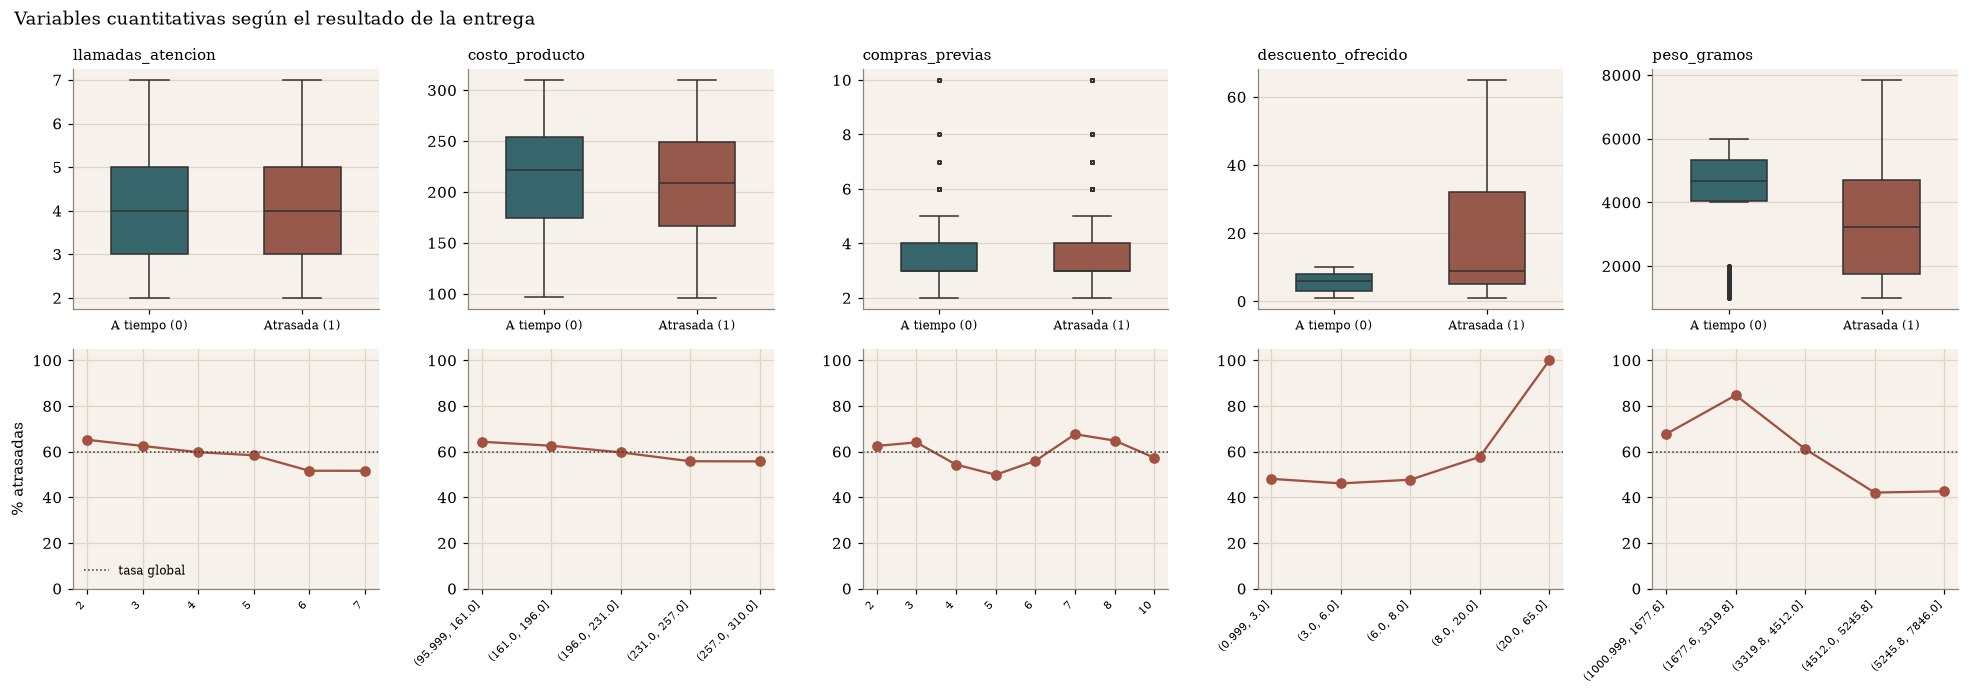

,media_a_tiempo,media_atrasada,mediana_a_tiempo,mediana_atrasada,d_cohen
variable,,,,,
descuento_ofrecido,5.546,18.664,6.0,9.0,0.882
peso_gramos,4168.668,3272.640,4674.0,3231.0,-0.569
costo_producto,214.499,207.289,222.0,209.0,-0.150
llamadas_atencion,4.148,3.991,4.0,4.0,-0.137
compras_previas,3.670,3.498,3.0,3.0,-0.113


In [15]:
def tramos(s):
    """Valores originales si hay pocos; quintiles en otro caso."""
    return s if s.nunique() <= 15 else pd.qcut(s, 5, duplicates='drop')

k = len(cuantitativas)
fig, ax = plt.subplots(2, k, figsize=(3.6 * k, 6.4))
etiquetas = df[TARGET].map(ETIQ_TARGET)
for j, v in enumerate(cuantitativas):
    sns.boxplot(x=etiquetas, y=df[v], hue=etiquetas, palette=PAL_TARGET, order=ETIQ_TARGET.values(),
                width=0.5, fliersize=2, flierprops={'alpha': 0.4}, legend=False, ax=ax[0, j])
    ax[0, j].set_title(v, fontsize=10)
    ax[0, j].set_xlabel('')
    ax[0, j].set_ylabel('')
    ax[0, j].tick_params(axis='x', labelsize=8)

    tasa = df.groupby(tramos(df[v]), observed=True)[TARGET].mean() * 100
    ax[1, j].plot(range(len(tasa)), tasa.values, marker='o', color=TERRA)
    ax[1, j].axhline(tasa_global * 100, color='#333333', ls=':', lw=1, label='tasa global')
    ax[1, j].set_xticks(range(len(tasa)), [str(t) for t in tasa.index], rotation=45, ha='right', fontsize=7.5)
    ax[1, j].set_ylim(0, 105)
    ax[1, j].set_ylabel('% atrasadas' if j == 0 else '')
ax[1, 0].legend(loc='lower left', fontsize=8, frameon=False)
fig.suptitle('Variables cuantitativas según el resultado de la entrega', x=0.01, ha='left', fontsize=12)
guardar('fig_eda_6_dependiente_vs_cuantitativas')

filas_rel = []
for v in cuantitativas:
    g0, g1 = df.loc[df[TARGET] == 0, v], df.loc[df[TARGET] == 1, v]
    sd_comb = np.sqrt(((len(g0) - 1) * g0.var() + (len(g1) - 1) * g1.var()) / (n - 2))
    filas_rel.append({'variable': v,
                      'media_a_tiempo': g0.mean(), 'media_atrasada': g1.mean(),
                      'mediana_a_tiempo': g0.median(), 'mediana_atrasada': g1.median(),
                      'd_cohen': (g1.mean() - g0.mean()) / sd_comb})
rel_cuanti = pd.DataFrame(filas_rel).set_index('variable')
rel_cuanti.to_csv(RAIZ / 'outputs/tablas/relacion_dependiente_cuantitativas.csv', encoding='utf-8')
rel_cuanti.sort_values('d_cohen', key=abs, ascending=False).round(3)

**Correlación de cada cuantitativa con el atraso.** Como la variable dependiente es binaria (0/1), la
correlación de Pearson equivale a la **punto-biserial**; se agrega la de **Spearman**, que usa rangos y es
robusta a la asimetría (descuento, compras previas) y a relaciones monótonas no lineales. El signo indica
la dirección: positivo = valores altos van con más atraso. Se informa el valor *p* como referencia
descriptiva; las pruebas formales están en la sección 3.

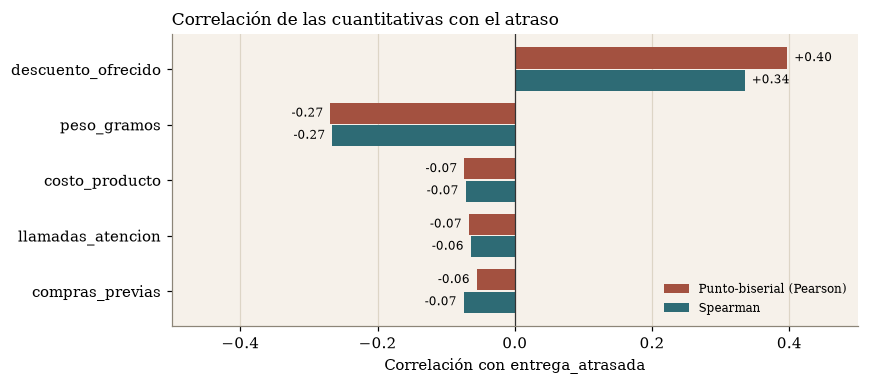

,r_punto_biserial,p_punto_biserial,rho_spearman,p_spearman
variable,,,,
descuento_ofrecido,0.397,0.0e+00,0.335,8.0e-287
peso_gramos,-0.269,2.4e-181,-0.266,1.9e-177
costo_producto,-0.074,1.1e-14,-0.072,4.5e-14
llamadas_atencion,-0.067,1.8e-12,-0.064,1.5e-11
compras_previas,-0.056,5.7e-09,-0.075,4.6e-15


In [16]:
from scipy.stats import pointbiserialr, spearmanr

filas_corr = []
for v in cuantitativas:
    r_pb, p_pb = pointbiserialr(df[TARGET], df[v])
    rho_s, p_s = spearmanr(df[v], df[TARGET])
    filas_corr.append({'variable': v, 'r_punto_biserial': r_pb, 'p_punto_biserial': p_pb,
                       'rho_spearman': rho_s, 'p_spearman': p_s})
corr_y = pd.DataFrame(filas_corr).set_index('variable').sort_values('r_punto_biserial', key=abs)
corr_y.to_csv(RAIZ / 'outputs/tablas/correlacion_dependiente_cuantitativas.csv', encoding='utf-8')

fig, ax = plt.subplots(figsize=(8, 3.6))
pos = np.arange(len(corr_y))
ax.barh(pos + 0.2, corr_y['r_punto_biserial'], height=0.38, color=TERRA, label='Punto-biserial (Pearson)')
ax.barh(pos - 0.2, corr_y['rho_spearman'], height=0.38, color=TEAL, label='Spearman')
for y, (r, s) in enumerate(zip(corr_y['r_punto_biserial'], corr_y['rho_spearman'])):
    for val, dy in [(r, 0.2), (s, -0.2)]:
        ax.text(val + (0.01 if val >= 0 else -0.01), y + dy, f'{val:+.2f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)
ax.axvline(0, color='#333333', lw=0.8)
ax.set_yticks(pos, corr_y.index)
ax.set_xlim(-0.5, 0.5)
ax.set_xlabel('Correlación con entrega_atrasada')
ax.set_title('Correlación de las cuantitativas con el atraso')
ax.grid(axis='y', visible=False)
ax.legend(loc='lower right', fontsize=8, frameon=False)
guardar('fig_eda_7_correlacion_dependiente')

vista = corr_y.iloc[::-1].round(3)
vista[['p_punto_biserial', 'p_spearman']] = corr_y[['p_punto_biserial', 'p_spearman']].map(lambda p: f'{p:.1e}')
vista

**Cualitativas.** Tasa de atraso por categoría frente a la tasa global (línea punteada); el número sobre
cada barra es el tamaño de la categoría. La tabla resume la fuerza de asociación con la *V* de Cramér
(0 = sin asociación, 1 = asociación perfecta). Es una medida descriptiva; las pruebas formales se
reservan para la sección 3.

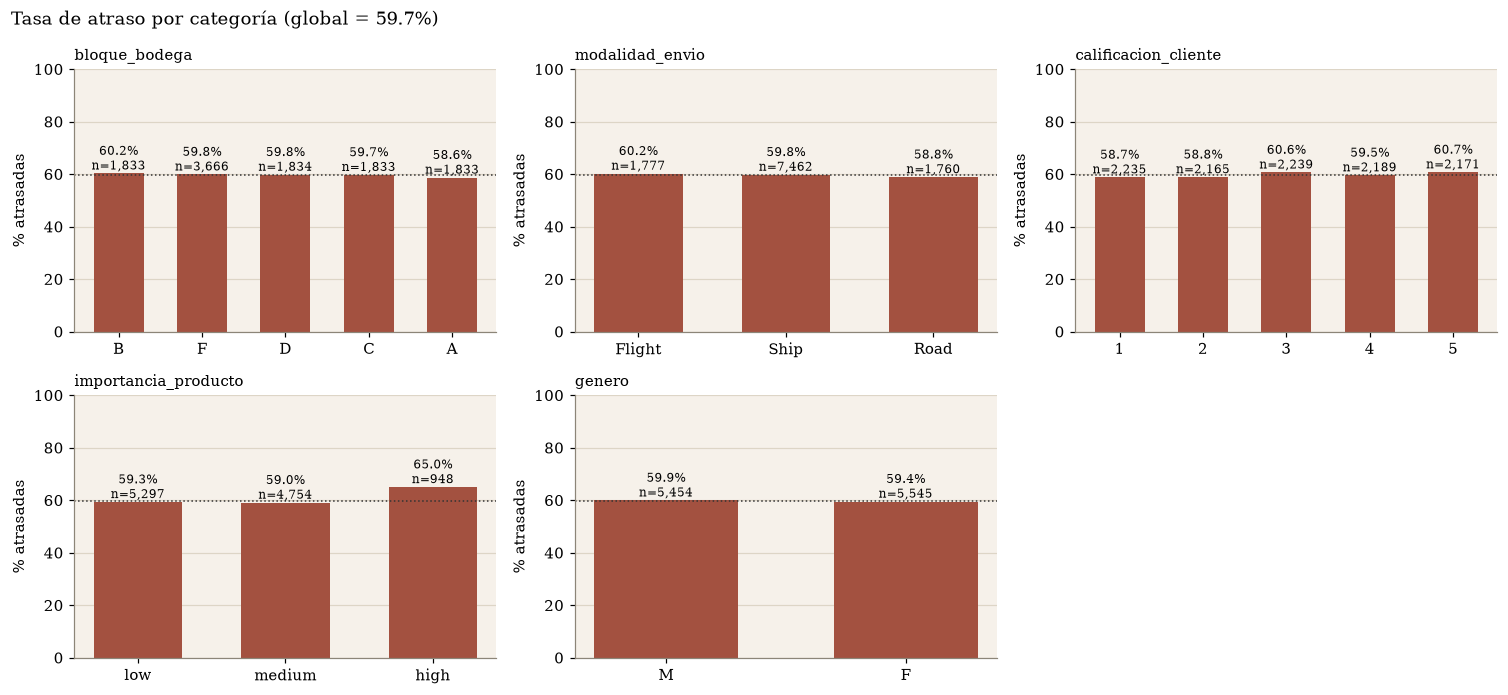

,categorias,tasa_min_%,tasa_max_%,V_cramer
variable,,,,
importancia_producto,3,59.045,64.979,0.033
calificacion_cliente,5,58.747,60.663,0.017
bloque_bodega,5,58.647,60.229,0.010
modalidad_envio,3,58.807,60.158,0.008
genero,2,59.441,59.901,0.005


In [17]:
fig, ax = rejilla(len(cualitativas))
filas_rel = []
for a, v in zip(ax, cualitativas):
    t = df.groupby(v, observed=True)[TARGET].agg(['mean', 'size'])
    if not es_ordinal(v):
        t = t.sort_values('mean', ascending=False)
    a.bar(t.index.astype(str), t['mean'] * 100, color=TERRA, width=0.6)
    a.axhline(tasa_global * 100, color='#333333', ls=':', lw=1)
    for i, (p, m) in enumerate(zip(t['mean'] * 100, t['size'])):
        a.text(i, p + 1.5, f'{p:.1f}%\nn={m:,}', ha='center', fontsize=8)
    a.set_ylim(0, 100)
    a.set_title(v, fontsize=10)
    a.set_ylabel('% atrasadas')
    a.grid(axis='x', visible=False)

    tabla = pd.crosstab(df[v], df[TARGET])
    filas_rel.append({'variable': v, 'categorias': len(tabla),
                      'tasa_min_%': t['mean'].min() * 100, 'tasa_max_%': t['mean'].max() * 100,
                      'V_cramer': association(tabla.values, method='cramer')})
fig.suptitle(f'Tasa de atraso por categoría (global = {tasa_global*100:.1f}%)', x=0.01, ha='left', fontsize=12)
guardar('fig_eda_8_dependiente_vs_cualitativas')

rel_cuali = pd.DataFrame(filas_rel).set_index('variable').sort_values('V_cramer', ascending=False)
rel_cuali.to_csv(RAIZ / 'outputs/tablas/relacion_dependiente_cualitativas.csv', encoding='utf-8')
rel_cuali.round(3)

#### (f) Interacción descuento × peso
Las dos variables más asociadas al atraso forman bloques nítidos en el *pairplot*. El mapa cruza ambas y
muestra la tasa de atraso de cada combinación (con su tamaño *n*). Una celda con tasa cercana a 100%
indica una regla casi determinista: dentro de ella el resultado no varía (**separación completa**), lo que
conviene tener presente al estimar proporciones o aplicar pruebas en las secciones 2 y 3.

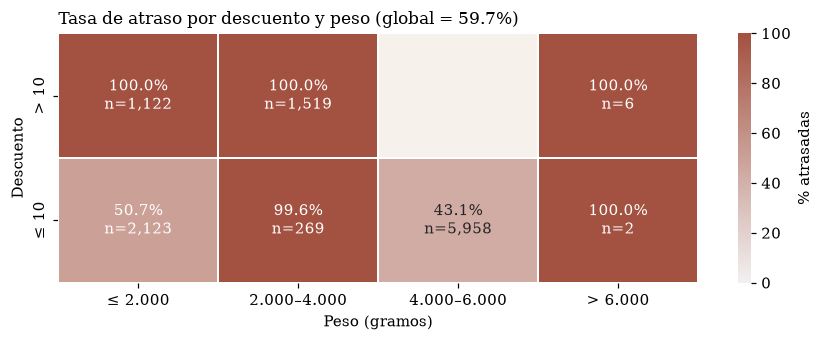

peso_gramos,≤ 2.000,2.000–4.000,4.000–6.000,> 6.000
> 10,100.0,100.0,NaN,100.0
≤ 10,50.7,99.6,43.1,100.0


In [18]:
UMBRAL_DESC = 10
desc_tramo = np.where(df['descuento_ofrecido'] > UMBRAL_DESC, f'> {UMBRAL_DESC}', f'≤ {UMBRAL_DESC}')
peso_tramo = pd.cut(df['peso_gramos'], [0, 2000, 4000, 6000, np.inf],
                    labels=['≤ 2.000', '2.000–4.000', '4.000–6.000', '> 6.000'])

cruce = df.groupby([desc_tramo, peso_tramo], observed=False)[TARGET].agg(['mean', 'size']).unstack()
tasa_cruce, n_cruce = cruce['mean'] * 100, cruce['size'].fillna(0).astype(int)
anot = tasa_cruce.map(lambda p: '' if pd.isna(p) else f'{p:.1f}%') + n_cruce.map(lambda m: f'\nn={m:,}')

fig, ax = plt.subplots(figsize=(8, 3.2))
sns.heatmap(tasa_cruce, annot=anot, fmt='', cmap=sns.light_palette(TERRA, as_cmap=True), vmin=0, vmax=100,
            linewidths=1, linecolor='white', cbar_kws={'label': '% atrasadas'}, ax=ax)
ax.grid(False)
ax.set_xlabel('Peso (gramos)')
ax.set_ylabel('Descuento')
ax.set_title(f'Tasa de atraso por descuento y peso (global = {tasa_global*100:.1f}%)')
guardar('fig_eda_9_descuento_x_peso')

tasa_cruce.round(1)

#### (g) Asociación entre las variables cualitativas
Complemento de la matriz de Spearman: *V* de Cramér para cada par de cualitativas. Valores cercanos a 0
indican que las variables no son redundantes entre sí.

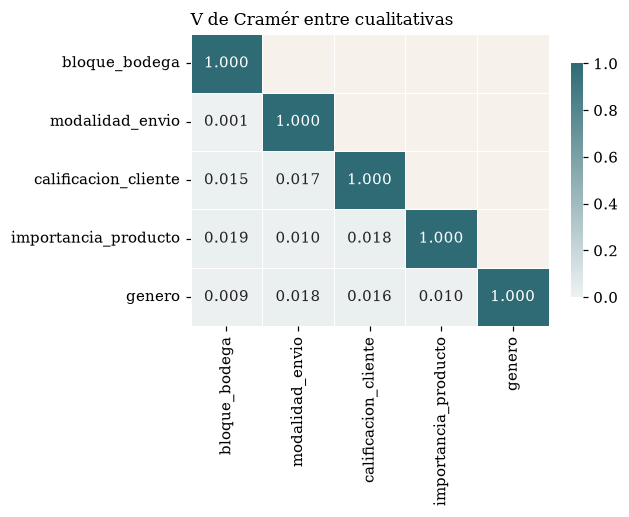

Modalidad de envío por bodega (% de fila):


modalidad_envio,Flight,Road,Ship
bloque_bodega,,,
A,16.2,16.0,67.8
B,16.1,16.0,67.8
C,16.1,16.0,67.9
D,16.2,15.9,67.9
F,16.1,16.0,67.9


In [19]:
cramer = pd.DataFrame(1.0, index=cualitativas, columns=cualitativas)
for i, a in enumerate(cualitativas):
    for b in cualitativas[i + 1:]:
        v = association(pd.crosstab(df[a], df[b]).values, method='cramer')
        cramer.loc[a, b] = cramer.loc[b, a] = v

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(cramer, mask=np.triu(np.ones_like(cramer, dtype=bool), k=1), annot=True, fmt='.3f',
            cmap=sns.light_palette(TEAL, as_cmap=True), vmin=0, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8}, ax=ax)
ax.grid(False)
ax.set_title('V de Cramér entre cualitativas')
guardar('fig_eda_10_cramer_cualitativas')

print('Modalidad de envío por bodega (% de fila):')
(pd.crosstab(df['bloque_bodega'], df['modalidad_envio'], normalize='index') * 100).round(1)

#### (h) Síntesis del EDA
Cifras clave calculadas a partir de las tablas anteriores (no se escriben a mano):

In [20]:
fuera_diag = lambda m: m.where(~np.eye(len(m), dtype=bool)).abs().stack()
top_cuanti = rel_cuanti['d_cohen'].abs().sort_values(ascending=False)
top_cuali = rel_cuali['V_cramer'].idxmax()
rho = fuera_diag(corr)
v_entre = fuera_diag(cramer)

print(f"Entregas atrasadas                    : {tasa_global*100:.1f}%")
for v in top_cuanti.index[:2]:
    print(f"d de Cohen {v:<27}: {rel_cuanti.loc[v, 'd_cohen']:+.2f}")
top_corr = corr_y['r_punto_biserial'].abs().idxmax()
print(f"Mayor correlación con el atraso       : r_pb = {corr_y.loc[top_corr, 'r_punto_biserial']:+.2f}, "
      f"rho = {corr_y.loc[top_corr, 'rho_spearman']:+.2f} ({top_corr})")
print(f"Mayor V de Cramér con el atraso       : {rel_cuali['V_cramer'].max():.3f} ({top_cuali})")
print(f"Mayor |rho| entre cuantitativas       : {rho.max():.2f} {rho.idxmax()}")
print(f"Mayor V de Cramér entre cualitativas  : {v_entre.max():.3f} {v_entre.idxmax()}")
alto = df[TARGET][df['descuento_ofrecido'] > UMBRAL_DESC]
medio = df[TARGET][df['peso_gramos'].between(2000, 4000, inclusive='right')]
print(f"Atraso con descuento > {UMBRAL_DESC}             : {alto.mean()*100:.1f}% (n = {len(alto):,})")
print(f"Atraso con peso 2.000–4.000 g         : {medio.mean()*100:.1f}% (n = {len(medio):,})")

Entregas atrasadas                    : 59.7%
d de Cohen descuento_ofrecido         : +0.88
d de Cohen peso_gramos                : -0.57
Mayor correlación con el atraso       : r_pb = +0.40, rho = +0.34 (descuento_ofrecido)
Mayor V de Cramér con el atraso       : 0.033 (importancia_producto)
Mayor |rho| entre cuantitativas       : 0.32 ('descuento_ofrecido', 'peso_gramos')
Mayor V de Cramér entre cualitativas  : 0.019 ('bloque_bodega', 'importancia_producto')
Atraso con descuento > 10             : 100.0% (n = 2,647)
Atraso con peso 2.000–4.000 g         : 99.9% (n = 1,788)


**Hallazgos**

- **Resultado desbalanceado de forma moderada**: cerca de 6 de cada 10 envíos llegan atrasados; las tasas
  por grupo se comparan contra esa referencia.
- **Descuento y peso concentran la asociación con el atraso**: mayor descuento y menor peso van con más
  atraso (efectos de magnitud grande y media según la *d* de Cohen, y las correlaciones más altas con el
  atraso, de signo positivo y negativo respectivamente). Costo, llamadas y compras previas muestran
  correlaciones débiles (|r| < 0,1) y diferencias pequeñas.
- **Separación completa**: con descuento sobre 10, o con peso entre 2.000 y 4.000 g, prácticamente todos los
  envíos se atrasan. Estas combinaciones no tienen variabilidad en el resultado.
- **Las cualitativas casi no se asocian con el atraso** (*V* de Cramér muy baja); la única diferencia visible
  es la mayor tasa en productos de importancia alta.
- **Predictoras poco redundantes**: las correlaciones entre cuantitativas son débiles y las cualitativas son
  prácticamente independientes entre sí.

**Implicaciones para las secciones 2 y 3.** Priorizar descuento, peso e importancia del producto en los
intervalos y pruebas de comparación entre grupos; con *n* ≈ 11.000, diferencias pequeñas pueden resultar
significativas, por lo que se reporta el tamaño de efecto junto al valor *p*.

## 2. Estimación puntual e intervalos de confianza (ID1.3)

Se estiman los cuatro parámetros definidos en el protocolo (P02 y P03). Intervalos al 95% con la
**aproximación normal** (Teorema Central del Límite):

- Media: $\bar{x} \pm z_{0.975}\cdot s/\sqrt{n}$
- Proporción: $\hat{p} \pm z_{0.975}\cdot\sqrt{\hat{p}(1-\hat{p})/n}$

| Parámetro | Estimador | Intervalo |
|---|---|---|
| Proporción de entregas atrasadas $p$ | $\hat p$ = atrasadas / registros válidos | Normal para una proporción |
| Peso medio $\mu_{peso}$ | $\bar x$ de `peso_gramos` | Normal para una media |
| Costo medio $\mu_{costo}$ | $\bar x$ de `costo_producto` | Normal para una media |
| Llamadas medias $\mu_{llamadas}$ | $\bar x$ de `llamadas_atencion` | Normal para una media (variable de conteo) |

Los intervalos describen la incertidumbre sobre el **parámetro** bajo los supuestos de independencia y de un
proceso generador comparable; **no** son rangos que contengan el 95% de los envíos.

In [21]:
from scipy import stats

NIVEL = 0.95
z975 = stats.norm.ppf(1 - (1 - NIVEL) / 2)


def ic_media(x):
    """Media e IC normal (TCL) con los registros válidos."""
    x = pd.Series(x).dropna()
    m, ee = x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    return {'estimacion': m, 'ee': ee, 'ic_inf': m - z975 * ee, 'ic_sup': m + z975 * ee, 'n': len(x)}


def ic_proporcion(x):
    """Proporción e IC normal (TCL) para una variable 0/1 con los registros válidos."""
    x = pd.Series(x).dropna()
    p, nn = x.mean(), len(x)
    ee = np.sqrt(p * (1 - p) / nn)
    return {'estimacion': p, 'ee': ee, 'ic_inf': p - z975 * ee, 'ic_sup': p + z975 * ee, 'n': nn}


print(f"z_0.975 = {z975:.4f}")

z_0.975 = 1.9600


### 2.1 Proporción de entregas atrasadas (P02)
La aproximación normal de la proporción es adecuada cuando $n\hat p$ y $n(1-\hat p)$ son grandes (regla
habitual: ambos ≥ 10); se verifica antes de calcular el intervalo.

In [22]:
pr = ic_proporcion(df[TARGET])
exitos, fracasos = pr['n'] * pr['estimacion'], pr['n'] * (1 - pr['estimacion'])
assert min(exitos, fracasos) >= 10      # condición para la aproximación normal

print(f"Registros válidos (n) : {pr['n']:,}")
print(f"n·p̂ = {exitos:,.0f}   n·(1-p̂) = {fracasos:,.0f}  (ambos ≥ 10)")
print(f"Proporción estimada   : {pr['estimacion']:.4f}   EE = {pr['ee']:.4f}")
print(f"IC 95%                : [{pr['ic_inf']:.4f}; {pr['ic_sup']:.4f}]   ancho = {pr['ic_sup'] - pr['ic_inf']:.4f}")

Registros válidos (n) : 10,999
n·p̂ = 6,563   n·(1-p̂) = 4,436  (ambos ≥ 10)
Proporción estimada   : 0.5967   EE = 0.0047
IC 95%                : [0.5875; 0.6059]   ancho = 0.0183


### 2.2 Medias de peso, costo y llamadas (P03)
**Supuestos del TCL.** La media muestral es aproximadamente normal aunque la variable no lo sea, siempre
que las observaciones sean independientes, la varianza sea finita y no haya valores que dominen la media.
Se revisa para cada variable: *n* efectivo, asimetría, extremos por la regla del IQR y el peso del 1% de
valores más altos en la suma total. El peso es **bimodal** (sección 1.5): la media es un parámetro válido,
pero cae entre las dos modas, por lo que se informa también la mediana como referencia descriptiva.

In [23]:
MEDIAS = {'peso_gramos': 'gramos', 'costo_producto': 'USD', 'llamadas_atencion': 'llamadas'}

filas_sup = []
for v in MEDIAS:
    s = df[v].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    top1 = s.nlargest(max(1, len(s) // 100)).sum() / s.sum() * 100
    filas_sup.append({'variable': v, 'n_efectivo': len(s), 'faltantes': int(df[v].isna().sum()),
                      'valores_distintos': s.nunique(), 'asimetria': s.skew(), 'curtosis_exceso': s.kurt(),
                      'extremos_IQR': int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()),
                      '%_suma_top1%': top1, 'media': s.mean(), 'mediana': s.median()})
supuestos_ic = pd.DataFrame(filas_sup).set_index('variable')
supuestos_ic.round(2)

,n_efectivo,faltantes,valores_distintos,asimetria,curtosis_exceso,extremos_IQR,%_suma_top1%,media,mediana
variable,,,,,,,,,
peso_gramos,10999,0,4034,-0.25,-1.45,0,1.65,3634.02,4149.0
costo_producto,10999,0,215,-0.16,-0.97,0,1.45,210.20,214.0
llamadas_atencion,10999,0,6,0.39,-0.31,0,1.71,4.05,4.0


In [24]:
PARAMETRO = {'peso_gramos': 'Peso medio', 'costo_producto': 'Costo medio',
             'llamadas_atencion': 'Llamadas medias'}

filas_ic = [{'parametro': 'Proporción de entregas atrasadas', 'variable': TARGET,
             'estimador': 'proporción muestral', 'unidad': 'proporción',
             'metodo': 'Normal (TCL)', **ic_proporcion(df[TARGET])}]
for v, unidad in MEDIAS.items():
    filas_ic.append({'parametro': PARAMETRO[v], 'variable': v, 'estimador': 'media muestral',
                     'unidad': unidad, 'metodo': 'Normal (TCL)', **ic_media(df[v])})

tabla_ic = pd.DataFrame(filas_ic).set_index('parametro')
tabla_ic['ancho'] = tabla_ic['ic_sup'] - tabla_ic['ic_inf']
tabla_ic['ancho_relativo_%'] = tabla_ic['ancho'] / tabla_ic['estimacion'] * 100
tabla_ic = tabla_ic[['variable', 'estimador', 'unidad', 'metodo', 'n', 'estimacion', 'ee',
                     'ic_inf', 'ic_sup', 'ancho', 'ancho_relativo_%']]
tabla_ic.to_csv(RAIZ / 'outputs/tablas/intervalos_confianza.csv', encoding='utf-8')
tabla_ic.round(4)

,variable,estimador,unidad,metodo,n,estimacion,ee,ic_inf,ic_sup,ancho,ancho_relativo_%
parametro,,,,,,,,,,,
Proporción de entregas atrasadas,entrega_atrasada,proporción muestral,proporción,Normal (TCL),10999,0.5967,0.0047,0.5875,0.6059,0.0183,3.0729
Peso medio,peso_gramos,media muestral,gramos,Normal (TCL),10999,3634.0167,15.5934,3603.4542,3664.5793,61.1251,1.6820
Costo medio,costo_producto,media muestral,USD,Normal (TCL),10999,210.1968,0.4583,209.2986,211.0951,1.7964,0.8547
Llamadas medias,llamadas_atencion,media muestral,llamadas,Normal (TCL),10999,4.0545,0.0109,4.0331,4.0758,0.0427,1.0523


### 2.3 Interpretación
Cada línea resume parámetro, estimación, intervalo, *n* efectivo y método (generado desde `tabla_ic`).

In [25]:
for param, f in tabla_ic.iterrows():
    if f['unidad'] == 'proporción':
        est, li, ls = (f'{100 * f[c]:.1f}%' for c in ('estimacion', 'ic_inf', 'ic_sup'))
    else:
        est, li, ls = (f"{f[c]:,.2f} {f['unidad']}" for c in ('estimacion', 'ic_inf', 'ic_sup'))
    print(f"- {param}: {est}. Con 95% de confianza, el valor poblacional está entre {li} y {ls} "
          f"(n = {f['n']:,}, {f['metodo']}).")

- Proporción de entregas atrasadas: 59.7%. Con 95% de confianza, el valor poblacional está entre 58.8% y 60.6% (n = 10,999, Normal (TCL)).
- Peso medio: 3,634.02 gramos. Con 95% de confianza, el valor poblacional está entre 3,603.45 gramos y 3,664.58 gramos (n = 10,999, Normal (TCL)).
- Costo medio: 210.20 USD. Con 95% de confianza, el valor poblacional está entre 209.30 USD y 211.10 USD (n = 10,999, Normal (TCL)).
- Llamadas medias: 4.05 llamadas. Con 95% de confianza, el valor poblacional está entre 4.03 llamadas y 4.08 llamadas (n = 10,999, Normal (TCL)).


**Lectura.**

- **Precisión alta**: con *n* ≈ 11.000 los intervalos son estrechos (su ancho equivale a entre 1% y 3% del
  valor estimado); la incertidumbre muestral es pequeña frente a otras fuentes de error, como el sesgo de
  selección o la falta de independencia, que el tamaño muestral no corrige.
- **La proporción de atraso es claramente mayor que 50%**: todo el intervalo queda sobre 0,5, por lo que la
  mayoría de los envíos llega atrasada.
- **La aproximación normal es razonable**: las variables no tienen colas pesadas ni extremos que dominen la
  media (asimetría baja, sin extremos por IQR), y el *n* es grande, por lo que el TCL aplica pese a la
  bimodalidad del peso y al carácter discreto de las llamadas.
- **Peso**: la media resume bien el total de carga, pero no a un envío típico; en una distribución bimodal
  la mediana describe mejor el centro.
- Los intervalos son **individuales** (sin ajuste por multiplicidad), según el protocolo.

**Nota: buena práctica y recomendación.** En esta fase se usa la aproximación normal que solicita el curso.
Con muestras pequeñas o proporciones cercanas a 0 o 1 se recomienda, en cambio:

- ***t* de Student para medias**: al estimar $\sigma$ con $s$, el cuantil $t_{0.975,\,n-1}$ incorpora esa
  incertidumbre adicional; con *n* pequeño, $z$ produce intervalos demasiado estrechos.
- **Wilson para proporciones**: el intervalo normal (Wald) puede tener una cobertura bastante inferior al 95%,
  salir de $[0, 1]$ o tener ancho cero si $\hat p = 0$ o $1$ (Brown, Cai y DasGupta, 2001). Wilson invierte la
  prueba *score*, se mantiene dentro de $[0, 1]$ y conserva una cobertura cercana a la nominal.

Con $n = 10.999$ y $\hat p \approx 0{,}60$, ambos métodos difieren de la aproximación normal recién en la cuarta
cifra decimal ($t_{0.975,\,10998} \approx 1{,}9602$ frente a $z_{0.975} = 1{,}9600$), por lo que aquí la
aproximación normal se usa sin pérdida. En subgrupos pequeños o con proporciones extremas, correspondería usar
*t* y Wilson.

## 3. Pruebas de hipótesis (ID1.4)

Nivel de significancia $\alpha = 0{,}05$, fijado antes de ejecutar las pruebas. Todas son **bilaterales**.
Las diferencias se calculan siempre como **atrasadas − puntuales**.

**Familia de Holm.** Antes de ver resultados se definió una sola familia con las **7 pruebas** que se
ejecutan: T01 (χ² modalidad), T02 (Welch peso), T03 (Welch costo) y las complementarias E1–E4. Cada prueba
reporta su valor *p* sin ajustar y una decisión **preliminar**; la decisión final se toma con el *p*
ajustado por Holm en la consolidación de la familia.

In [26]:
ALFA = 0.05


def fmt_p(p):
    return '< 0.0001' if p < 1e-4 else f'= {p:.4f}'


def decision(p):
    return 'se rechaza H0' if p < ALFA else 'no se rechaza H0'


def contraste_welch(x_atr, x_punt):
    """t de Welch bilateral para media(atrasadas) − media(puntuales), con IC y d_av."""
    x_atr, x_punt = pd.Series(x_atr).dropna(), pd.Series(x_punt).dropna()
    r = stats.ttest_ind(x_atr, x_punt, equal_var=False)
    ic = r.confidence_interval(NIVEL)
    dif = x_atr.mean() - x_punt.mean()
    return {'n_atr': len(x_atr), 'media_atr': x_atr.mean(), 'de_atr': x_atr.std(ddof=1),
            'n_punt': len(x_punt), 'media_punt': x_punt.mean(), 'de_punt': x_punt.std(ddof=1),
            'diferencia': dif, 'ic_inf': ic.low, 'ic_sup': ic.high,
            't': r.statistic, 'gl': r.df, 'p': r.pvalue,
            'd_av': dif / np.sqrt((x_atr.var(ddof=1) + x_punt.var(ddof=1)) / 2)}


def z_dos_proporciones(y1, y0):
    """z bilateral para p1 − p0 (EE con proporción combinada) e IC normal de la diferencia (EE no combinado)."""
    y1, y0 = pd.Series(y1).dropna(), pd.Series(y0).dropna()
    n1, n0, p1, p0 = len(y1), len(y0), y1.mean(), y0.mean()
    p_comb = (y1.sum() + y0.sum()) / (n1 + n0)
    z = (p1 - p0) / np.sqrt(p_comb * (1 - p_comb) * (1 / n1 + 1 / n0))
    ee = np.sqrt(p1 * (1 - p1) / n1 + p0 * (1 - p0) / n0)
    return {'n1': n1, 'p1': p1, 'n0': n0, 'p0': p0, 'diferencia': p1 - p0,
            'ic_inf': p1 - p0 - z975 * ee, 'ic_sup': p1 - p0 + z975 * ee,
            'z': z, 'p': 2 * stats.norm.sf(abs(z)), 'riesgo_relativo': p1 / p0}

### T01 Asociación entre modalidad de envío y atraso (χ² de independencia)

- $H_0$: la modalidad de envío y el resultado de la entrega son independientes.
- $H_1$: existe asociación entre ambas variables.

Estadístico $\chi^2 = \sum (O - E)^2 / E$, con $E = (\text{total fila} \times \text{total columna}) / n$ y
$gl = (r-1)(c-1) = 2$. Magnitud: $V = \sqrt{\chi^2 \big/ \left(n\,\min(r-1,\,c-1)\right)}$ (V de Cramér).

#### Supuestos
- **Frecuencias esperadas**: todas $\geq 5$. Si alguna fallara se justificaría una alternativa válida; no se
  fusionan modalidades para obtener significancia.
- **Independencia**: cada envío está en una sola celda. La independencia entre registros es un supuesto de
  diseño y no se puede verificar con los datos (protocolo §3).
- **Volumen y proporción**: la tabla separa el número de envíos de la proporción de atraso dentro de cada modalidad.

In [ ]:
VAR_T01 = 'modalidad_envio'
columnas = [ETIQ_TARGET[0], ETIQ_TARGET[1]]
observada = pd.crosstab(df[VAR_T01], df[TARGET].map(ETIQ_TARGET))[columnas]

chi2, p_chi, gl, esp = stats.chi2_contingency(observada)
esperada = pd.DataFrame(esp, index=observada.index, columns=observada.columns)

tasas = observada.assign(n=observada.sum(axis=1))
tasas['% atrasadas'] = tasas[ETIQ_TARGET[1]] / tasas['n'] * 100

print('Frecuencias observadas y tasa de atraso por modalidad:')
print(tasas.round(1).to_string())
print('\nFrecuencias esperadas bajo independencia:')
print(esperada.round(1).to_string())
print(f"\nFrecuencia esperada mínima: {esperada.values.min():.1f}  "
      f"(celdas con E < 5: {int((esperada.values < 5).sum())} de {esperada.size})")
print(f"Unidades: {int(observada.values.sum()):,} envíos, cada uno en una sola celda")

In [ ]:
n_t01 = int(observada.values.sum())
v_cramer = np.sqrt(chi2 / (n_t01 * (min(observada.shape) - 1)))
assert np.isclose(v_cramer, association(observada.values, method='cramer'))
residuos = (observada - esperada) / np.sqrt(esperada)    # residuos de Pearson

print(f"χ² = {chi2:.3f}   gl = {gl}   valor p {fmt_p(p_chi)}")
print(f"V de Cramér = {v_cramer:.4f}")
print('Decisión preliminar (sin ajuste):', decision(p_chi))
print('\nResiduos de Pearson (O − E) / √E:')
print(residuos.round(2).to_string())

contraste_modalidad = pd.DataFrame([{
    'codigo': 'T01', 'contraste': 'Asociación entre modalidad de envío y atraso',
    'h0': 'Independencia', 'h1': 'Asociación', 'metodo': 'χ² de independencia',
    'variable': VAR_T01, 'n': n_t01, 'chi2': chi2, 'gl': gl, 'p': p_chi,
    'v_cramer': v_cramer, 'frec_esperada_min': esperada.values.min(),
    'alfa': ALFA, 'decision_sin_ajuste': decision(p_chi)}])
contraste_modalidad.to_csv(RAIZ / 'outputs/tablas/contraste_modalidad.csv', index=False, encoding='utf-8')
contraste_modalidad.T

In [ ]:
t_min, t_max = tasas['% atrasadas'].min(), tasas['% atrasadas'].max()
print(f"- La tasa de atraso es casi la misma en las tres modalidades: de {t_min:.1f}% "
      f"({tasas['% atrasadas'].idxmin()}) a {t_max:.1f}% ({tasas['% atrasadas'].idxmax()}).")
print(f"- χ² = {chi2:.2f}, gl = {gl}, p {fmt_p(p_chi)}: {decision(p_chi)} (preliminar, antes de Holm).")
print(f"- Magnitud: V de Cramér = {v_cramer:.3f}, asociación prácticamente nula.")

**Lectura.**

- **Resultado**: los datos no aportan evidencia de asociación entre modalidad y atraso. No rechazar $H_0$ no
  demuestra que sean independientes; con *n* ≈ 11.000 una asociación de magnitud relevante se habría detectado,
  y $V \approx 0{,}008$ indica una magnitud despreciable.
- **Volumen y proporción**: Ship concentra el 67,8% de los envíos y, por eso, la mayoría de los atrasos, pero su
  proporción de atraso (59,8%) es igual a la de las otras modalidades.
- **Supuestos**: todas las frecuencias esperadas superan 700; la independencia entre registros no es verificable.
- **Alcance**: es una asociación observacional; no se fusionaron ni recodificaron modalidades.
- La decisión final depende del *p* ajustado por Holm.

### T02 Diferencia de peso medio entre entregas atrasadas y puntuales (Welch)

Sea $\Delta_{peso} = \mu_{atrasadas} - \mu_{puntuales}$ (en gramos):

- $H_0:\ \Delta_{peso} = 0$
- $H_1:\ \Delta_{peso} \neq 0$

Se usa la prueba *t* de **Welch** porque no supone varianzas iguales y es robusta con grupos de distinto
tamaño: $t = (\bar x_{atr} - \bar x_{punt}) \big/ \sqrt{s_{atr}^2/n_{atr} + s_{punt}^2/n_{punt}}$, con grados
de libertad de Welch-Satterthwaite.

#### Supuestos
- **Tamaños**: *n* de cada grupo.
- **Distribución**: forma del peso en cada grupo (la sección 1.5 mostró que es bimodal).
- **Dispersión**: desviaciones estándar y razón de varianzas (Welch no exige que sean iguales).
- **Independencia**: grupos disjuntos (cada envío pertenece a un solo grupo) e `id_envio` único. La
  independencia entre registros no es verificable con los datos: es un supuesto de diseño (protocolo §3).
- **Influencia**: cambio máximo de la diferencia al quitar una observación, $|x_i - \bar x_g|/(n_g - 1)$, y
  sensibilidad sin los extremos IQR de cada grupo (solo informativo: no se eliminan, protocolo §10).

In [27]:
VAR_T02 = 'peso_gramos'
atr = df.loc[df[TARGET] == 1, VAR_T02]
punt = df.loc[df[TARGET] == 0, VAR_T02]


def es_extremo(x):
    q1, q3 = x.quantile([0.25, 0.75])
    return (x < q1 - 1.5 * (q3 - q1)) | (x > q3 + 1.5 * (q3 - q1))


filas_sup = []
for g, x in [(ETIQ_TARGET[1], atr), (ETIQ_TARGET[0], punt)]:
    filas_sup.append({'grupo': g, 'n': len(x), 'media': x.mean(), 'mediana': x.median(),
                      'de': x.std(ddof=1), 'asimetria': x.skew(), 'curtosis_exceso': x.kurt(),
                      'extremos_IQR': int(es_extremo(x).sum()),
                      'influencia_max_g': (x - x.mean()).abs().max() / (len(x) - 1)})
supuestos_t02 = pd.DataFrame(filas_sup).set_index('grupo')

dif = atr.mean() - punt.mean()
dif_sin_ext = atr[~es_extremo(atr)].mean() - punt[~es_extremo(punt)].mean()
print(f"Independencia: grupos disjuntos = {atr.index.intersection(punt.index).empty}, "
      f"id_envio único = {df['id_envio'].is_unique}")
print(f"Razón de varianzas (atr/punt)        : {atr.var() / punt.var():.3f}")
print(f"Diferencia de medias                 : {dif:,.1f} g")
print(f"Máximo cambio al quitar 1 observación: {supuestos_t02['influencia_max_g'].max():.2f} g "
      f"({supuestos_t02['influencia_max_g'].max() / abs(dif) * 100:.3f}% de la diferencia)")
print(f"Diferencia sin extremos IQR          : {dif_sin_ext:,.1f} g (sensibilidad, no se eliminan)")
supuestos_t02.round(2)

Independencia: grupos disjuntos = True, id_envio único = True
Razón de varianzas (atr/punt)        : 1.003
Diferencia de medias                 : -896.0 g
Máximo cambio al quitar 1 observación: 0.71 g (0.080% de la diferencia)
Diferencia sin extremos IQR          : -1,721.1 g (sensibilidad, no se eliminan)


,n,media,mediana,de,asimetria,curtosis_exceso,extremos_IQR,influencia_max_g
grupo,,,,,,,,
Atrasada (1),6563,3272.64,3231.0,1576.15,0.14,-1.38,0,0.70
A tiempo (0),4436,4168.67,4674.0,1573.95,-0.93,-0.64,1046,0.71


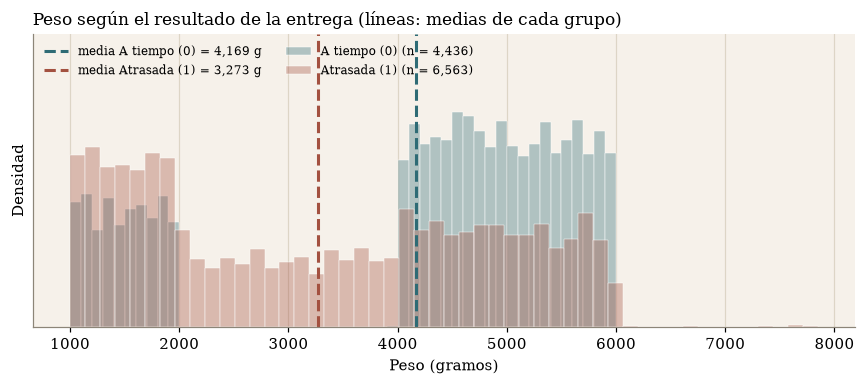

In [28]:
fig, ax = plt.subplots(figsize=(8, 3.6))
for g, x in [(ETIQ_TARGET[0], punt), (ETIQ_TARGET[1], atr)]:
    sns.histplot(x, ax=ax, stat='density', bins=50, color=PAL_TARGET[g], alpha=0.35,
                 edgecolor='white', linewidth=0.3, label=f'{g} (n = {len(x):,})')
    ax.axvline(x.mean(), color=PAL_TARGET[g], lw=2, ls='--', label=f'media {g} = {x.mean():,.0f} g')
ax.set_xlabel('Peso (gramos)')
ax.set_ylabel('Densidad')
ax.set_yticks([])
ax.set_title('Peso según el resultado de la entrega (líneas: medias de cada grupo)')
ax.set_ylim(0, ax.get_ylim()[1] * 1.3)   # espacio para la leyenda
ax.legend(frameon=False, fontsize=8, loc='upper left', ncol=2)
ax.grid(axis='y', visible=False)
guardar('fig_t02_peso_grupos')

#### Prueba
El intervalo de confianza de la diferencia usa el mismo error estándar y los mismos grados de libertad de
Welch que el estadístico, por lo que es coherente con la prueba.

In [29]:
t02 = contraste_welch(atr, punt)

print(f"Atrasadas : media = {t02['media_atr']:,.1f} g   DE = {t02['de_atr']:,.1f}   n = {t02['n_atr']:,}")
print(f"Puntuales : media = {t02['media_punt']:,.1f} g   DE = {t02['de_punt']:,.1f}   n = {t02['n_punt']:,}")
print(f"Diferencia (atrasada − puntual): {t02['diferencia']:,.1f} g")
print(f"IC 95% de la diferencia        : [{t02['ic_inf']:,.1f}; {t02['ic_sup']:,.1f}] g")
print(f"t de Welch = {t02['t']:.2f}   gl = {t02['gl']:,.1f}   valor p {fmt_p(t02['p'])}")
print('Decisión preliminar (sin ajuste):', decision(t02['p']))

Atrasadas : media = 3,272.6 g   DE = 1,576.1   n = 6,563
Puntuales : media = 4,168.7 g   DE = 1,574.0   n = 4,436
Diferencia (atrasada − puntual): -896.0 g
IC 95% de la diferencia        : [-956.0; -836.0] g
t de Welch = -29.27   gl = 9,526.6   valor p < 0.0001
Decisión preliminar (sin ajuste): se rechaza H0


#### Tamaño de efecto estandarizado
$$d_{av} = \frac{\bar x_{atr} - \bar x_{punt}}{\sqrt{\left(s_{atr}^2 + s_{punt}^2\right)/2}}$$

**Denominador**: raíz del **promedio simple** de las dos varianzas muestrales (no ponderado por *n*), según
el protocolo §8. Mantiene el signo de la diferencia (negativo = las atrasadas pesan menos) y expresa la
diferencia en desviaciones estándar. A diferencia de la *d* de Cohen de la sección 1.5, que usa la desviación
combinada ponderada por $n-1$, no da más peso al grupo más grande. No se fijan umbrales de importancia
operacional sin respaldo externo.

In [30]:
d_cohen_eda = rel_cuanti.loc[VAR_T02, 'd_cohen']
print(f"d_av                        = {t02['d_av']:+.3f}")
print(f"d de Cohen (DE ponderada)   = {d_cohen_eda:+.3f}  (sección 1.5, como referencia)")

contraste_peso = pd.DataFrame([{
    'codigo': 'T02', 'contraste': 'Diferencia de peso medio (atrasada − puntual)',
    'h0': 'Δpeso = 0', 'h1': 'Δpeso ≠ 0', 'metodo': 't de Welch bilateral',
    'variable': VAR_T02, 'unidad': 'gramos', **t02, 'alfa': ALFA,
    'decision_sin_ajuste': decision(t02['p']),
    'formula_d_av': '(media_atr - media_punt) / sqrt((var_atr + var_punt) / 2)'}])
contraste_peso.to_csv(RAIZ / 'outputs/tablas/contraste_peso.csv', index=False, encoding='utf-8')
contraste_peso.T

d_av                        = -0.569
d de Cohen (DE ponderada)   = -0.569  (sección 1.5, como referencia)


,0
codigo,T02
contraste,Diferencia de peso medio (atrasada − puntual)
h0,Δpeso = 0
h1,Δpeso ≠ 0
metodo,t de Welch bilateral
variable,peso_gramos
unidad,gramos
n_atr,6563
media_atr,3272.640104
de_atr,1576.148391


#### Interpretación

In [31]:
print(f"- Las entregas atrasadas pesan en promedio {abs(t02['diferencia']):,.0f} g menos que las puntuales "
      f"({t02['media_atr']:,.0f} g frente a {t02['media_punt']:,.0f} g).")
print(f"- Con 95% de confianza, la diferencia poblacional está entre {t02['ic_inf']:,.0f} y {t02['ic_sup']:,.0f} g; "
      f"el intervalo no incluye 0.")
print(f"- t = {t02['t']:.2f}, gl = {t02['gl']:,.0f}, p {fmt_p(t02['p'])}: {decision(t02['p'])} (preliminar, antes de Holm).")
print(f"- Magnitud: d_av = {t02['d_av']:+.2f}, es decir, la diferencia equivale a {abs(t02['d_av']):.2f} "
      f"desviaciones estándar.")

- Las entregas atrasadas pesan en promedio 896 g menos que las puntuales (3,273 g frente a 4,169 g).
- Con 95% de confianza, la diferencia poblacional está entre -956 y -836 g; el intervalo no incluye 0.
- t = -29.27, gl = 9,527, p < 0.0001: se rechaza H0 (preliminar, antes de Holm).
- Magnitud: d_av = -0.57, es decir, la diferencia equivale a 0.57 desviaciones estándar.


**Lectura.**

- **Magnitud y significancia**: la diferencia es grande en gramos y en unidades estandarizadas; con *n* ≈
  11.000 incluso diferencias pequeñas serían significativas, por eso se reporta la magnitud junto al valor *p*.
- **Supuestos**: ambos grupos son grandes, sin colas pesadas y con dispersión casi idéntica, y ninguna
  observación individual mueve la diferencia de forma apreciable (< 1 g). El TCL respalda la normalidad
  aproximada de las medias pese a la bimodalidad.
- **Sensibilidad**: los extremos IQR de las puntuales son los envíos livianos (≤ 2.000 g), extremos solo
  dentro de ese grupo. Al excluirlos, la diferencia casi se duplica, pero mantiene el signo. Son valores
  válidos y se conservan (protocolo §10); la sensibilidad indica que la **magnitud** de la diferencia
  depende de la mezcla de pesos livianos en cada grupo, mientras que la **dirección** es robusta.
- **Alcance**: la diferencia de medias resume un patrón **no monótono** (sección 1.5: el tramo de 2.000–4.000 g
  concentra casi todos los atrasos y el de 4.000–6.000 g tiene la menor tasa). No implica que "más peso
  cause menos atraso", ni que el efecto sea lineal; es una asociación observacional.
- La decisión final depende del *p* ajustado por Holm en la familia de 7 pruebas.

### Pruebas complementarias E1–E4
Forman parte de la **familia de Holm de 7 pruebas**. Cada una reporta el *p* sin ajustar y una decisión
preliminar.

| Código | Pregunta | Método |
|---|---|---|
| E1 | ¿La distribución del peso difiere entre atrasadas y puntuales? | Mann-Whitney *U* (robustez de T02, no depende de la media) |
| E2 | ¿La tasa de atraso difiere entre productos de importancia alta y el resto? | *z* de dos proporciones |
| E3 | ¿La tasa de atraso difiere entre descuento > 10 y ≤ 10? | *z* de dos proporciones |
| E4 | ¿El descuento medio difiere entre atrasadas y puntuales? | *t* de Welch |

Prueba *z* de dos proporciones: $z = (\hat p_1-\hat p_0)\big/\sqrt{\hat p(1-\hat p)(1/n_1+1/n_0)}$, con
$\hat p$ la proporción combinada; el IC de la diferencia usa el error estándar no combinado
$\sqrt{\hat p_1(1-\hat p_1)/n_1 + \hat p_0(1-\hat p_0)/n_0}$.

#### E1 Mann-Whitney: peso de atrasadas vs. puntuales
$H_0$: la distribución del peso es la misma en ambos grupos (ningún grupo tiende a valores mayores).
$H_1$: un grupo tiende a pesos mayores que el otro. Efecto: **correlación biserial de rangos**
$r = 2U/(n_{atr}\,n_{punt}) - 1$, entre −1 y 1 (negativo = las atrasadas tienden a pesar menos).

In [32]:
mw = stats.mannwhitneyu(atr, punt, alternative='two-sided')
r_rb = 2 * mw.statistic / (len(atr) * len(punt)) - 1

print(f"Mediana atrasadas = {atr.median():,.0f} g   Mediana puntuales = {punt.median():,.0f} g")
print(f"U = {mw.statistic:,.0f}   valor p {fmt_p(mw.pvalue)}   r biserial de rangos = {r_rb:+.3f}")
print('Decisión preliminar (sin ajuste):', decision(mw.pvalue))

Mediana atrasadas = 3,231 g   Mediana puntuales = 4,674 g
U = 10,000,332   valor p < 0.0001   r biserial de rangos = -0.313
Decisión preliminar (sin ajuste): se rechaza H0


#### E2 Tasa de atraso: importancia alta vs. resto
$H_0:\ p_{alta} = p_{resto}$ vs. $H_1:\ p_{alta} \neq p_{resto}$. Es la única cualitativa con una diferencia
visible en la sección 1.5.

In [33]:
alta = df['importancia_producto'] == 'high'
e2 = z_dos_proporciones(df.loc[alta, TARGET], df.loc[~alta, TARGET])

print(f"Importancia alta : {e2['p1']*100:.1f}% atrasadas (n = {e2['n1']:,})")
print(f"Resto            : {e2['p0']*100:.1f}% atrasadas (n = {e2['n0']:,})")
print(f"Diferencia = {e2['diferencia']*100:+.1f} pp   IC 95% [{e2['ic_inf']*100:+.1f}; {e2['ic_sup']*100:+.1f}] pp")
print(f"z = {e2['z']:.2f}   valor p {fmt_p(e2['p'])}   riesgo relativo = {e2['riesgo_relativo']:.2f}")
print('Decisión preliminar (sin ajuste):', decision(e2['p']))

Importancia alta : 65.0% atrasadas (n = 948)
Resto            : 59.2% atrasadas (n = 10,051)
Diferencia = +5.8 pp   IC 95% [+2.6; +9.0] pp
z = 3.49   valor p = 0.0005   riesgo relativo = 1.10
Decisión preliminar (sin ajuste): se rechaza H0


#### E3 Tasa de atraso: descuento > 10 vs. ≤ 10
$H_0:\ p_{>10} = p_{\le 10}$ vs. $H_1:\ p_{>10} \neq p_{\le 10}$. **Advertencia**: hay separación completa
($\hat p_{>10} = 1$), por lo que ese grupo no aporta varianza al error estándar no combinado del IC; el
intervalo refleja solo la incertidumbre del grupo ≤ 10. La prueba *z* (con proporción combinada) sigue
siendo calculable.

In [34]:
desc_alto = df['descuento_ofrecido'] > UMBRAL_DESC
e3 = z_dos_proporciones(df.loc[desc_alto, TARGET], df.loc[~desc_alto, TARGET])

print(f"Descuento > {UMBRAL_DESC} : {e3['p1']*100:.1f}% atrasadas (n = {e3['n1']:,})")
print(f"Descuento ≤ {UMBRAL_DESC} : {e3['p0']*100:.1f}% atrasadas (n = {e3['n0']:,})")
print(f"Diferencia = {e3['diferencia']*100:+.1f} pp   IC 95% [{e3['ic_inf']*100:+.1f}; {e3['ic_sup']*100:+.1f}] pp")
print(f"z = {e3['z']:.2f}   valor p {fmt_p(e3['p'])}   riesgo relativo = {e3['riesgo_relativo']:.2f}")
print('Decisión preliminar (sin ajuste):', decision(e3['p']))

Descuento > 10 : 100.0% atrasadas (n = 2,647)
Descuento ≤ 10 : 46.9% atrasadas (n = 8,352)
Diferencia = +53.1 pp   IC 95% [+52.0; +54.2] pp
z = 48.54   valor p < 0.0001   riesgo relativo = 2.13
Decisión preliminar (sin ajuste): se rechaza H0


#### E4 Descuento medio: atrasadas vs. puntuales (Welch)
$H_0:\ \Delta_{desc} = 0$ vs. $H_1:\ \Delta_{desc} \neq 0$, con $\Delta_{desc} = \mu_{atrasadas} - \mu_{puntuales}$.
Mismo método y tamaño de efecto ($d_{av}$) que T02. La unidad del descuento no está confirmada (protocolo
§10, regla 7), por lo que la diferencia se expresa en las unidades originales del archivo.

In [35]:
e4 = contraste_welch(df.loc[df[TARGET] == 1, 'descuento_ofrecido'], df.loc[df[TARGET] == 0, 'descuento_ofrecido'])

print(f"Atrasadas : media = {e4['media_atr']:.2f}   DE = {e4['de_atr']:.2f}   n = {e4['n_atr']:,}")
print(f"Puntuales : media = {e4['media_punt']:.2f}   DE = {e4['de_punt']:.2f}   n = {e4['n_punt']:,}")
print(f"Diferencia = {e4['diferencia']:.2f}   IC 95% [{e4['ic_inf']:.2f}; {e4['ic_sup']:.2f}]")
print(f"t de Welch = {e4['t']:.2f}   gl = {e4['gl']:,.1f}   valor p {fmt_p(e4['p'])}   d_av = {e4['d_av']:+.3f}")
print('Decisión preliminar (sin ajuste):', decision(e4['p']))

Atrasadas : media = 18.66   DE = 19.11   n = 6,563
Puntuales : media = 5.55   DE = 2.88   n = 4,436
Diferencia = 13.12   IC 95% [12.65; 13.59]
t de Welch = 54.70   gl = 6,998.1   valor p < 0.0001   d_av = +0.960
Decisión preliminar (sin ajuste): se rechaza H0


#### Resumen de las pruebas complementarias
Exportado a `outputs/tablas/contrastes_complementarios.csv`. Las columnas `codigo` y `p` coinciden con
`contraste_peso.csv`, para consolidar las 7 pruebas y aplicar Holm.

In [36]:
contrastes_compl = pd.DataFrame([
    {'codigo': 'E1', 'prueba': 'Mann-Whitney U: peso atrasadas vs puntuales', 'estadistico': 'U',
     'valor_estadistico': mw.statistic, 'p': mw.pvalue, 'efecto': 'r biserial de rangos', 'valor_efecto': r_rb},
    {'codigo': 'E2', 'prueba': 'z dos proporciones: atraso importancia alta vs resto', 'estadistico': 'z',
     'valor_estadistico': e2['z'], 'p': e2['p'], 'efecto': 'diferencia de proporciones', 'valor_efecto': e2['diferencia']},
    {'codigo': 'E3', 'prueba': f'z dos proporciones: atraso descuento > {UMBRAL_DESC} vs <= {UMBRAL_DESC}', 'estadistico': 'z',
     'valor_estadistico': e3['z'], 'p': e3['p'], 'efecto': 'diferencia de proporciones', 'valor_efecto': e3['diferencia']},
    {'codigo': 'E4', 'prueba': 'Welch: descuento medio atrasadas vs puntuales', 'estadistico': 't',
     'valor_estadistico': e4['t'], 'p': e4['p'], 'efecto': 'd_av', 'valor_efecto': e4['d_av']},
])
contrastes_compl['decision_sin_ajuste'] = contrastes_compl['p'].map(decision)
contrastes_compl.to_csv(RAIZ / 'outputs/tablas/contrastes_complementarios.csv', index=False, encoding='utf-8')
contrastes_compl.assign(p=contrastes_compl['p'].map(lambda p: f'{p:.1e}')).round(3)

,codigo,prueba,estadistico,valor_estadistico,p,efecto,valor_efecto,decision_sin_ajuste
0,E1,Mann-Whitney U: peso atrasadas vs puntuales,U,1.000033e+07,3.4e-171,r biserial de rangos,-0.313,se rechaza H0
1,E2,z dos proporciones: atraso importancia alta vs...,z,3.486000e+00,4.9e-04,diferencia de proporciones,0.058,se rechaza H0
2,E3,z dos proporciones: atraso descuento > 10 vs <...,z,4.854000e+01,0.0e+00,diferencia de proporciones,0.531,se rechaza H0
3,E4,Welch: descuento medio atrasadas vs puntuales,t,5.470300e+01,0.0e+00,d_av,0.960,se rechaza H0
